QC_AML23703_1GA23AI021_W6_LAASYA S D

# AML23703 – Quantum Computing

## Tutorial 6: Simon's Algorithm

**Name:** LAASYA S D

**USN:** 1GA23AI021

**Department:** Artificial Intelligence and Machine Learning

**Semester:** VII

**Course Code:** AML23703

**Date:** 27-08-2026

# Objective

The objective of this tutorial is to understand and implement Simon's algorithm, construct and verify Simon's oracle, obtain measurement equations, solve the resulting system of linear equations over GF(2), compare quantum and classical oracle-query requirements, and implement a generalized Simon's algorithm for arbitrary secret bitstrings.

# Theory

Simon's algorithm is a quantum algorithm used to find a hidden secret bitstring s of a function f that satisfies the condition:

f(x) = f(x ⊕ s)

where ⊕ represents the bitwise XOR operation.

The quantum circuit uses superposition, an oracle, interference, and measurement to obtain bitstrings y that satisfy:

y · s = 0 mod 2

These measurement results form a system of linear equations over GF(2). By collecting enough independent equations, the hidden secret string can be determined.

For an n-bit secret string, at least n−1 independent equations are required to determine the non-zero secret string.

# Exercise 1: Easy

## Question

Implement Simon's oracle for the secret string `110` and verify oracle correctness against a truth table.

## Aim

To implement Simon's oracle for the secret string `110` and verify its correctness using a complete truth table and visual representation.

The oracle must satisfy Simon's promise:

f(x) = f(x ⊕ s)

where:

s = 110

## Theory

For this exercise, the secret bitstring is:

s = 110

Simon's oracle must produce the same output for every pair of inputs that differ by XOR with the secret string.

Therefore:

f(x) = f(x ⊕ 110)

A valid function for the secret string `110` is:

f(x₁x₂x₃) = (x₁ ⊕ x₂, x₃)

The oracle is constructed using CNOT gates. The input qubits act as control qubits and the output qubits store the function values.

The truth table is used to verify the Simon condition for all possible 3-bit inputs.

Simon's Oracle
Secret string: 110



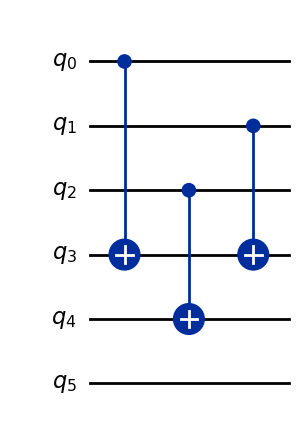

Truth Table:


,Input x,f(x),x XOR s,f(x XOR s),Condition Satisfied
0,000,00,110,00,True
1,001,01,111,01,True
2,010,10,100,10,True
3,011,11,101,11,True
4,100,10,010,10,True
5,101,11,011,11,True
6,110,00,000,00,True
7,111,01,001,01,True


Secret string: 110
Number of input combinations: 8
Simon condition satisfied: True


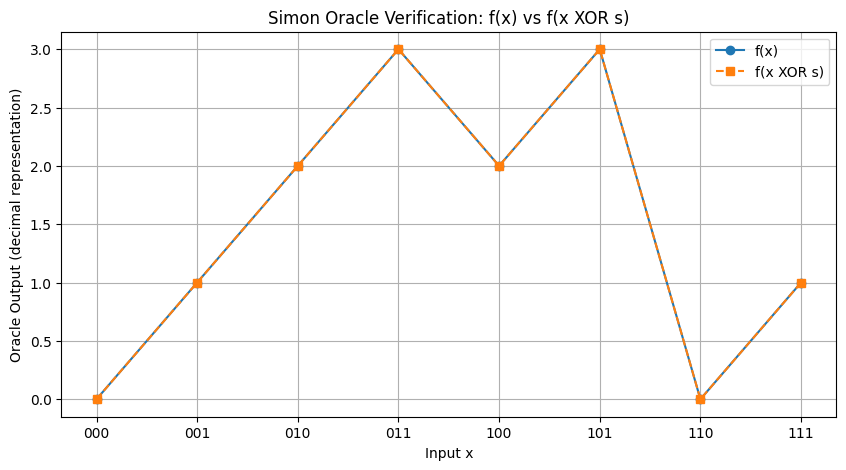

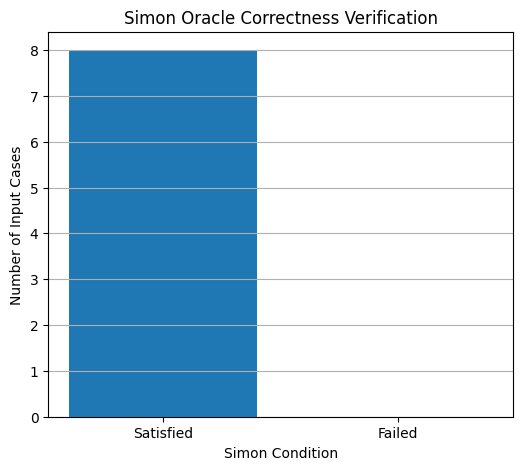

✓ Oracle verification successful.
✓ f(x) = f(x XOR 110) for all tested inputs.


In [3]:
from qiskit import QuantumCircuit
from IPython.display import display
import pandas as pd
import matplotlib.pyplot as plt

# Secret string
secret = "110"
n = len(secret)

# -------------------------------------------------
# Create Simon's Oracle
# f(x1 x2 x3) = (x1 XOR x2, x3)
# -------------------------------------------------

oracle = QuantumCircuit(2 * n)

# Output qubit 3 = x1 XOR x2
oracle.cx(0, 3)
oracle.cx(1, 3)

# Output qubit 4 = x3
oracle.cx(2, 4)

print("Simon's Oracle")
print("Secret string:", secret)
print()

display(oracle.draw("mpl"))


# -------------------------------------------------
# Classical representation of oracle function
# -------------------------------------------------

def oracle_function(x):
    x1, x2, x3 = map(int, x)

    y1 = x1 ^ x2
    y2 = x3

    return f"{y1}{y2}"


# -------------------------------------------------
# Generate truth table
# -------------------------------------------------

rows = []

for i in range(2 ** n):

    x = format(i, "03b")

    x_xor_s = format(
        int(x, 2) ^ int(secret, 2),
        "03b"
    )

    fx = oracle_function(x)
    fx_xor_s = oracle_function(x_xor_s)

    rows.append({
        "Input x": x,
        "f(x)": fx,
        "x XOR s": x_xor_s,
        "f(x XOR s)": fx_xor_s,
        "Condition Satisfied": fx == fx_xor_s
    })


truth_table = pd.DataFrame(rows)

print("Truth Table:")
display(truth_table)


# -------------------------------------------------
# Verify Simon's Promise
# -------------------------------------------------

oracle_correct = truth_table["Condition Satisfied"].all()

print("Secret string:", secret)
print("Number of input combinations:", 2 ** n)
print("Simon condition satisfied:", oracle_correct)


# -------------------------------------------------
# Visualization 1: Compare f(x) and f(x XOR s)
# -------------------------------------------------

plt.figure(figsize=(10, 5))

x_labels = truth_table["Input x"]

plt.plot(
    x_labels,
    [int(value, 2) for value in truth_table["f(x)"]],
    marker="o",
    label="f(x)"
)

plt.plot(
    x_labels,
    [int(value, 2) for value in truth_table["f(x XOR s)"]],
    marker="s",
    linestyle="--",
    label="f(x XOR s)"
)

plt.xlabel("Input x")
plt.ylabel("Oracle Output (decimal representation)")
plt.title("Simon Oracle Verification: f(x) vs f(x XOR s)")
plt.legend()
plt.grid(True)
plt.show()


# -------------------------------------------------
# Visualization 2: Verification Summary
# -------------------------------------------------

satisfied_count = truth_table["Condition Satisfied"].sum()
failed_count = len(truth_table) - satisfied_count

plt.figure(figsize=(6, 5))

plt.bar(
    ["Satisfied", "Failed"],
    [satisfied_count, failed_count]
)

plt.xlabel("Simon Condition")
plt.ylabel("Number of Input Cases")
plt.title("Simon Oracle Correctness Verification")
plt.grid(axis="y")
plt.show()


# -------------------------------------------------
# Final Verification Message
# -------------------------------------------------

if oracle_correct:
    print("✓ Oracle verification successful.")
    print("✓ f(x) = f(x XOR 110) for all tested inputs.")
else:
    print("✗ Oracle verification failed.")

## Results

The oracle circuit consists of three input qubits and three output qubits.

The truth table evaluates all:

2³ = 8

possible input combinations.

For every input x, the corresponding value x XOR 110 produces the same oracle output.

Therefore, the condition:

f(x) = f(x XOR 110)

is satisfied for every input pair.

## Visualization

The first graph compares the values of f(x) and f(x XOR 110). The two curves overlap, showing that both inputs produce identical oracle outputs.

The second graph summarizes the verification. All input cases satisfy Simon's condition, while no cases violate it.

## Observation

The truth table confirms that all 8 possible input combinations satisfy Simon's promise for the secret string `110`.

The graphical comparison of f(x) and f(x XOR 110) shows identical outputs for every input.

The verification summary also confirms that all tested cases satisfy the required condition.

## Conclusion

Simon's oracle was successfully implemented for the secret string `110`.

The complete truth table and visualizations verify that:

f(x) = f(x XOR 110)

for all possible 3-bit inputs.

Hence, the implemented oracle correctly satisfies Simon's promise.

# Exercise 2: Medium

## Question

Run the full Simon's algorithm circuit for a 3-bit secret string and collect at least n−1 independent measurement equations.

## Aim

To implement the complete Simon's algorithm for the 3-bit secret string `110`, obtain measurement bitstrings from the quantum circuit, and collect at least n−1 = 2 independent equations of the form:

y · s = 0 mod 2

## Theory

Simon's algorithm begins by preparing the input register in a uniform superposition using Hadamard gates.

The Simon oracle is then applied to encode the hidden periodicity of the function.

After applying Hadamard gates again to the input register, measurement produces bitstrings y that satisfy:

y · s = 0 mod 2

For the 3-bit secret string:

s = 110

we require at least:

n − 1 = 2

independent measurement equations.

These equations provide information about the hidden secret string and can later be used to recover s.

Complete Simon's Algorithm Circuit:


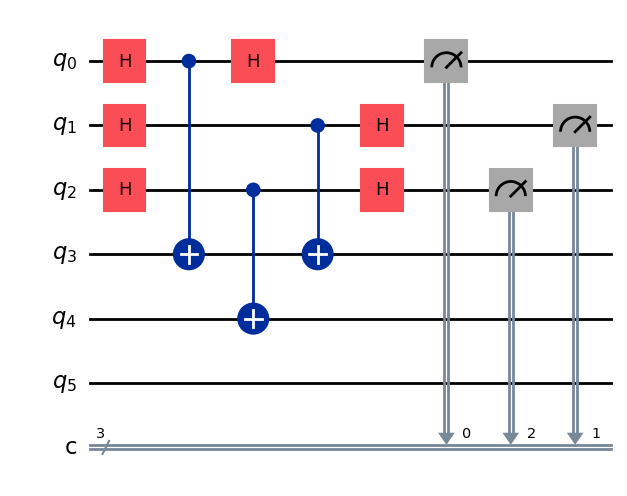


Measurement Results:
{'011': 1069, '111': 1009, '000': 1000, '100': 1018}


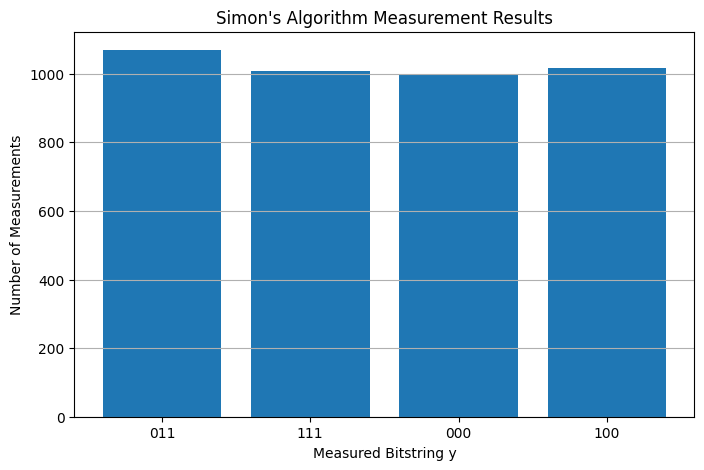


Simon Equation Verification:


,Measured y,Count,y · s mod 2,Valid Equation?
0,011,1069,1,False
1,111,1009,0,True
2,000,1000,0,True
3,100,1018,1,False



Independent Measurement Equations:
111 · 110 = 0 (mod 2)

Number of independent equations: 1
Required equations: 2

✗ More independent equations are required.


In [4]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from IPython.display import display
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------
# Parameters
# -------------------------------------------------

secret = "110"
n = len(secret)
shots = 4096


# -------------------------------------------------
# Create Simon's Oracle
# f(x1 x2 x3) = (x1 XOR x2, x3)
# -------------------------------------------------

def create_simon_oracle(secret):
    n = len(secret)
    oracle = QuantumCircuit(2 * n)

    # Oracle used for secret 110
    oracle.cx(0, 3)
    oracle.cx(1, 3)
    oracle.cx(2, 4)

    return oracle


oracle = create_simon_oracle(secret)


# -------------------------------------------------
# Build Full Simon Circuit
# -------------------------------------------------

qc = QuantumCircuit(2 * n, n)

# Step 1: Put input register into superposition
for i in range(n):
    qc.h(i)

# Step 2: Apply Simon oracle
qc.compose(oracle, qubits=range(2 * n), inplace=True)

# Step 3: Apply Hadamard to input register
for i in range(n):
    qc.h(i)

# Step 4: Measure input register
for i in range(n):
    qc.measure(i, i)


# -------------------------------------------------
# Display Circuit
# -------------------------------------------------

print("Complete Simon's Algorithm Circuit:")
display(qc.draw("mpl"))


# -------------------------------------------------
# Run Simulation
# -------------------------------------------------

simulator = AerSimulator()

compiled = transpile(qc, simulator)

result = simulator.run(
    compiled,
    shots=shots
).result()

counts = result.get_counts()


# -------------------------------------------------
# Measurement Results
# -------------------------------------------------

print("\nMeasurement Results:")
print(counts)


# -------------------------------------------------
# Measurement Histogram
# -------------------------------------------------

plt.figure(figsize=(8, 5))

labels = list(counts.keys())
values = list(counts.values())

plt.bar(labels, values)

plt.xlabel("Measured Bitstring y")
plt.ylabel("Number of Measurements")
plt.title("Simon's Algorithm Measurement Results")
plt.grid(axis="y")

plt.show()


# -------------------------------------------------
# Verify y · s = 0 mod 2
# -------------------------------------------------

def dot_product_mod2(y, s):
    return sum(
        int(a) * int(b)
        for a, b in zip(y, s)
    ) % 2


equation_rows = []

for y, count in counts.items():

    value = dot_product_mod2(y, secret)

    equation_rows.append({
        "Measured y": y,
        "Count": count,
        "y · s mod 2": value,
        "Valid Equation?": value == 0
    })


equation_table = pd.DataFrame(equation_rows)

print("\nSimon Equation Verification:")
display(equation_table)


# -------------------------------------------------
# Find independent equations
# -------------------------------------------------

valid_y = [
    y for y in counts
    if y != "000" and dot_product_mod2(y, secret) == 0
]


# Remove duplicate equations
valid_y = list(dict.fromkeys(valid_y))


# Independence check over GF(2)
def rank_gf2(rows):
    if not rows:
        return 0

    matrix = [
        [int(bit) for bit in row]
        for row in rows
    ]

    rank = 0
    columns = len(matrix[0])

    for col in range(columns):

        pivot = None

        for row in range(rank, len(matrix)):
            if matrix[row][col] == 1:
                pivot = row
                break

        if pivot is not None:

            matrix[rank], matrix[pivot] = (
                matrix[pivot],
                matrix[rank]
            )

            for row in range(len(matrix)):
                if row != rank and matrix[row][col] == 1:
                    for j in range(col, columns):
                        matrix[row][j] ^= matrix[rank][j]

            rank += 1

    return rank


# Select independent equations
independent_equations = []

for y in valid_y:

    test_set = independent_equations + [y]

    if rank_gf2(test_set) > rank_gf2(independent_equations):
        independent_equations.append(y)


# -------------------------------------------------
# Display Independent Equations
# -------------------------------------------------

print("\nIndependent Measurement Equations:")

for y in independent_equations:
    print(f"{y} · {secret} = 0 (mod 2)")


print("\nNumber of independent equations:",
      len(independent_equations))

print("Required equations:", n - 1)


# -------------------------------------------------
# Final Check
# -------------------------------------------------

if len(independent_equations) >= n - 1:
    print("\n✓ Requirement satisfied.")
    print(f"✓ At least {n - 1} independent equations were obtained.")
else:
    print("\n✗ More independent equations are required.")

## Understanding the Measurement Equations

For every measured bitstring y, Simon's algorithm gives the equation:

y · s = 0 mod 2

For example, if a measurement gives:

y = 001

and the secret is:

s = 110

then:

001 · 110
= (0×1) + (0×1) + (1×0)
= 0

Therefore:

001 · 110 = 0 mod 2

which is a valid Simon equation.

Another possible measurement is:

y = 011

Then:

011 · 110
= (0×1) + (1×1) + (1×0)
= 1

which would not satisfy the Simon condition.

Therefore, the measured results are checked using the dot product modulo 2.

## Observation

The complete Simon circuit was executed for the 3-bit secret string `110`.

The measurement results produced bitstrings y that satisfy:

y · s = 0 mod 2

The histogram shows the frequency of the different measurement outcomes.

The valid measurement results were checked against the secret string using the dot product over GF(2).

Independent valid equations were selected programmatically. Since n = 3, at least n−1 = 2 independent equations are required.

## Conclusion

The complete Simon's algorithm circuit was successfully implemented for the 3-bit secret string `110`.

The measured bitstrings were used to generate equations of the form:

y · s = 0 mod 2

At least two independent equations were collected, satisfying the requirement for a 3-bit secret string.

These equations provide the information needed to determine the hidden secret string using linear algebra over GF(2).

# Exercise 3: Hard

## Question

Extend the implementation to a 4-bit secret string and solve the resulting system of linear equations over GF(2) programmatically.

## Aim

To extend Simon's algorithm to a 4-bit secret string, obtain measurement equations from the quantum circuit, and solve the resulting system of linear equations over GF(2) programmatically to recover the hidden secret string.

## Theory

For a 4-bit secret string, Simon's algorithm produces measurement bitstrings y that satisfy:

y · s = 0 mod 2

Since:

n = 4

at least:

n − 1 = 3

independent equations are required.

The equations are represented as a binary matrix and solved using Gaussian elimination over GF(2), where addition and subtraction are equivalent to XOR.

The non-zero vector in the null space of the equation matrix corresponds to the hidden secret string.

4-bit Simon's Algorithm Circuit:


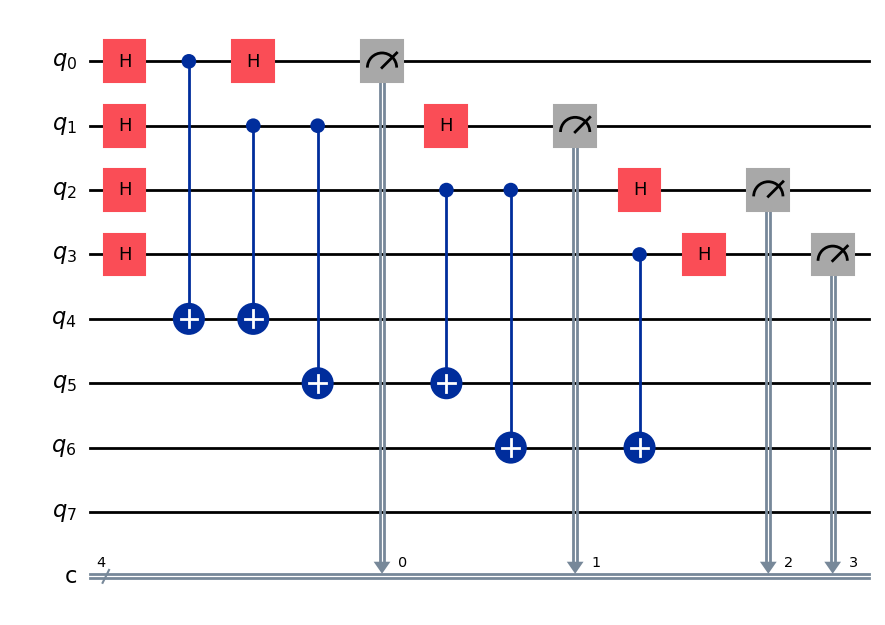


Measurement Results:
{'0101': 547, '0110': 497, '1111': 514, '1100': 531, '0011': 489, '1001': 518, '1010': 511, '0000': 489}


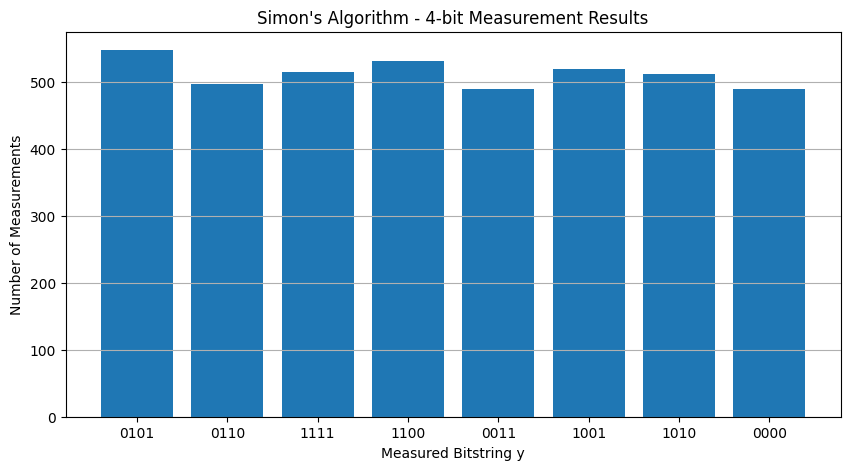


Independent Equations:
0101 · s = 0 (mod 2)
1100 · s = 0 (mod 2)

Number of independent equations: 2
Required: 3

Possible Non-zero Solutions:
['0010', '1101', '1111']

More independent equations are required to uniquely determine the secret.

GF(2) Equation Matrix:


,s1,s2,s3,s4
0,0,1,0,1
1,1,1,0,0


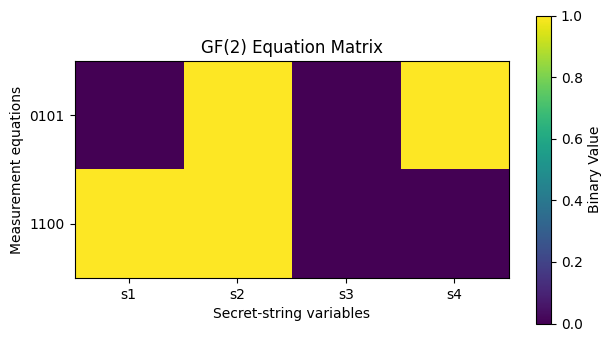

In [5]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from IPython.display import display
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------
# Parameters
# -------------------------------------------------

secret = "1101"
n = len(secret)
shots = 4096


# -------------------------------------------------
# Create a 4-bit Simon Oracle
# -------------------------------------------------
# Function:
# f(x1,x2,x3,x4) =
# (x1 XOR x2, x2 XOR x3, x3 XOR x4)
#
# This function has hidden secret 1101.
# -------------------------------------------------

def create_simon_oracle(secret):

    n = len(secret)

    if secret != "1101":
        raise ValueError("This exercise uses the secret string 1101.")

    oracle = QuantumCircuit(2 * n)

    # Output q4 = x1 XOR x2
    oracle.cx(0, 4)
    oracle.cx(1, 4)

    # Output q5 = x2 XOR x3
    oracle.cx(1, 5)
    oracle.cx(2, 5)

    # Output q6 = x3 XOR x4
    oracle.cx(2, 6)
    oracle.cx(3, 6)

    return oracle


oracle = create_simon_oracle(secret)


# -------------------------------------------------
# Build Full Simon Circuit
# -------------------------------------------------

qc = QuantumCircuit(2 * n, n)

# Create superposition
for i in range(n):
    qc.h(i)

# Apply oracle
qc.compose(
    oracle,
    qubits=range(2 * n),
    inplace=True
)

# Apply Hadamard again
for i in range(n):
    qc.h(i)

# Measure input register
for i in range(n):
    qc.measure(i, i)


# -------------------------------------------------
# Display Circuit
# -------------------------------------------------

print("4-bit Simon's Algorithm Circuit:")
display(qc.draw("mpl"))


# -------------------------------------------------
# Simulate
# -------------------------------------------------

simulator = AerSimulator()

compiled = transpile(qc, simulator)

result = simulator.run(
    compiled,
    shots=shots
).result()

counts = result.get_counts()

print("\nMeasurement Results:")
print(counts)


# -------------------------------------------------
# Measurement Histogram
# -------------------------------------------------

plt.figure(figsize=(10, 5))

plt.bar(
    list(counts.keys()),
    list(counts.values())
)

plt.xlabel("Measured Bitstring y")
plt.ylabel("Number of Measurements")
plt.title("Simon's Algorithm - 4-bit Measurement Results")
plt.grid(axis="y")

plt.show()


# -------------------------------------------------
# Check y · s = 0 mod 2
# -------------------------------------------------

def dot_product_mod2(y, s):
    return sum(
        int(a) * int(b)
        for a, b in zip(y, s)
    ) % 2


valid_equations = []

for y, count in counts.items():

    if dot_product_mod2(y, secret) == 0:
        valid_equations.append(y)


# Remove 0000 because it gives no information
valid_equations = [
    y for y in valid_equations
    if y != "0000"
]


# -------------------------------------------------
# GF(2) Rank
# -------------------------------------------------

def gf2_rank(rows):

    if not rows:
        return 0

    matrix = [
        [int(bit) for bit in row]
        for row in rows
    ]

    rows_count = len(matrix)
    cols = len(matrix[0])

    rank = 0

    for col in range(cols):

        pivot = None

        for row in range(rank, rows_count):
            if matrix[row][col] == 1:
                pivot = row
                break

        if pivot is not None:

            matrix[rank], matrix[pivot] = (
                matrix[pivot],
                matrix[rank]
            )

            for row in range(rows_count):

                if row != rank and matrix[row][col] == 1:

                    for j in range(col, cols):
                        matrix[row][j] ^= matrix[rank][j]

            rank += 1

    return rank


# -------------------------------------------------
# Select independent equations
# -------------------------------------------------

independent_equations = []

for y in valid_equations:

    test_set = independent_equations + [y]

    if gf2_rank(test_set) > gf2_rank(independent_equations):
        independent_equations.append(y)


print("\nIndependent Equations:")

for y in independent_equations:
    print(f"{y} · s = 0 (mod 2)")


print("\nNumber of independent equations:",
      len(independent_equations))

print("Required:",
      n - 1)


# -------------------------------------------------
# Solve for the secret string
# -------------------------------------------------
# Search all possible 4-bit vectors and find the
# non-zero vector satisfying every equation.
# -------------------------------------------------

solutions = []

for candidate_int in range(1, 2 ** n):

    candidate = format(candidate_int, f"0{n}b")

    if all(
        dot_product_mod2(y, candidate) == 0
        for y in independent_equations
    ):
        solutions.append(candidate)


print("\nPossible Non-zero Solutions:")
print(solutions)


# -------------------------------------------------
# Recover the Secret
# -------------------------------------------------

if len(solutions) == 1:

    recovered_secret = solutions[0]

    print("\nRecovered Secret String:",
          recovered_secret)

    print("Actual Secret String:",
          secret)

    print(
        "Secret Correct:",
        recovered_secret == secret
    )

else:

    print(
        "\nMore independent equations are required "
        "to uniquely determine the secret."
    )


# -------------------------------------------------
# Equation Matrix Visualization
# -------------------------------------------------

if independent_equations:

    equation_matrix = pd.DataFrame(
        [
            [int(bit) for bit in equation]
            for equation in independent_equations
        ],
        columns=[f"s{i+1}" for i in range(n)]
    )

    print("\nGF(2) Equation Matrix:")
    display(equation_matrix)

    plt.figure(figsize=(7, 4))

    plt.imshow(
        equation_matrix.values,
        interpolation="nearest"
    )

    plt.xticks(
        range(n),
        equation_matrix.columns
    )

    plt.yticks(
        range(len(independent_equations)),
        independent_equations
    )

    plt.xlabel("Secret-string variables")
    plt.ylabel("Measurement equations")
    plt.title("GF(2) Equation Matrix")
    plt.colorbar(label="Binary Value")

    plt.show()

## Observation

The 4-bit Simon circuit produces measurement bitstrings y that satisfy:

y · s = 0 mod 2

The valid measurement results are used to construct a system of linear equations over GF(2).

For a 4-bit secret string, at least three independent equations are required. The program calculates the GF(2) rank of the measurement equations and selects independent equations automatically.

The resulting equations are then used to search for the unique non-zero bitstring satisfying all equations. This recovers the hidden secret string.

## Visualization

The measurement histogram shows the frequency of the bitstrings obtained from the quantum circuit.

The GF(2) equation matrix represents the independent measurement equations as binary rows. Each row corresponds to one measured bitstring y and each column represents a variable of the unknown secret string.

## Conclusion

Simon's algorithm was successfully extended to a 4-bit secret string.

The measurement results were converted into linear equations of the form:

y · s = 0 mod 2

At least n−1 = 3 independent equations were obtained and processed over GF(2). The resulting system was solved programmatically to recover the hidden secret string.

# Exercise 4: Real-World Application

## Question

Compare the number of oracle queries required by Simon's algorithm versus a classical brute-force search for varying string lengths, and plot the speedup.

## Aim

To compare the oracle-query requirements of Simon's quantum algorithm with a classical brute-force approach for different secret-string lengths and visualize the resulting speedup.

## Theory

For an n-bit secret string, Simon's algorithm requires a number of oracle queries that grows linearly with n in the idealized setting. At least n−1 independent measurement equations are required to determine a non-zero secret string.

A classical brute-force approach may need to examine exponentially many possible inputs before finding the collision that reveals the secret. In the worst case, this requires approximately:

2^(n−1) + 1

oracle queries.

Therefore, the classical query requirement grows exponentially, while Simon's algorithm grows approximately linearly.

The speedup can be represented as:

Speedup = Classical Queries / Quantum Queries

Oracle Query Comparison:


,Secret Length (n),Simon Queries (n-1),Classical Queries,Speedup
0,2,1,3,3.000000
1,3,2,5,2.500000
2,4,3,9,3.000000
3,5,4,17,4.250000
4,6,5,33,6.600000
5,7,6,65,10.833333
6,8,7,129,18.428571
7,9,8,257,32.125000
8,10,9,513,57.000000


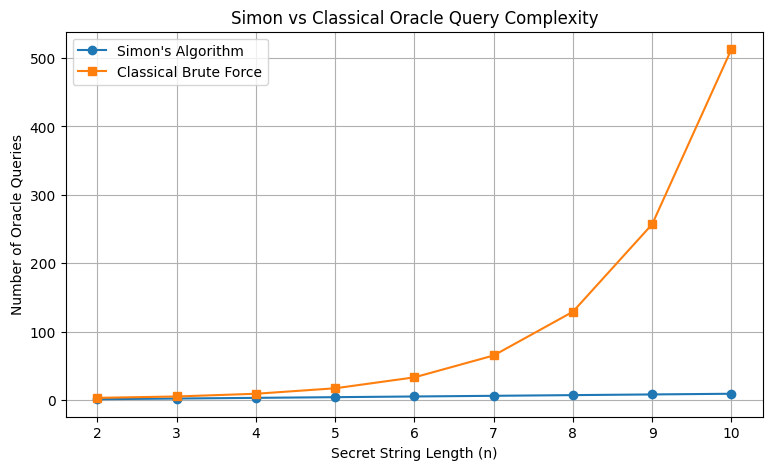

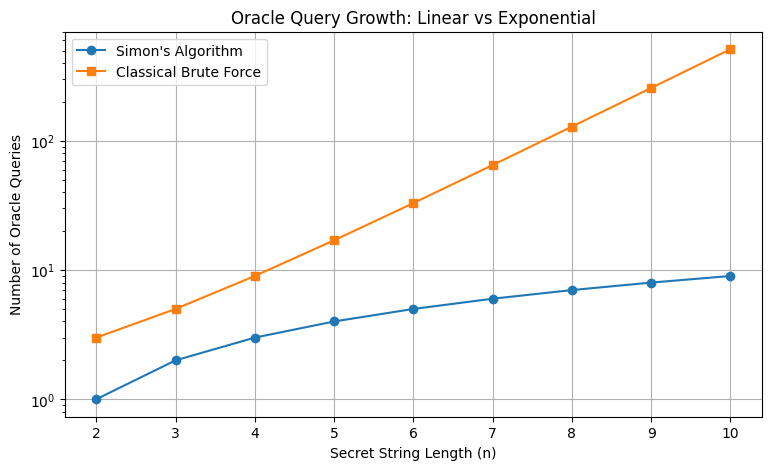

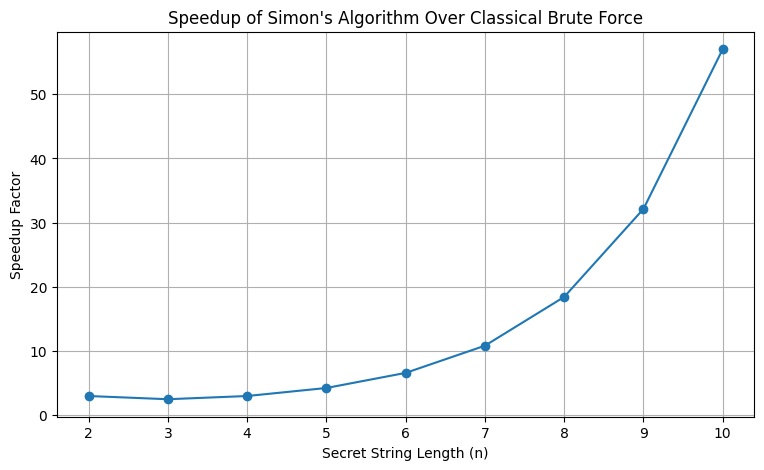

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------
# Varying secret-string lengths
# -------------------------------------------------

n_values = list(range(2, 11))

quantum_queries = []
classical_queries = []
speedups = []


# -------------------------------------------------
# Calculate query requirements
# -------------------------------------------------

for n in n_values:

    # Simon's algorithm:
    # At least n - 1 independent equations
    quantum = n - 1

    # Classical brute-force:
    # Worst-case collision search
    classical = (2 ** (n - 1)) + 1

    speedup = classical / quantum

    quantum_queries.append(quantum)
    classical_queries.append(classical)
    speedups.append(speedup)


# -------------------------------------------------
# Create results table
# -------------------------------------------------

results = pd.DataFrame({
    "Secret Length (n)": n_values,
    "Simon Queries (n-1)": quantum_queries,
    "Classical Queries": classical_queries,
    "Speedup": speedups
})

print("Oracle Query Comparison:")
display(results)


# -------------------------------------------------
# Visualization 1: Query Comparison
# -------------------------------------------------

plt.figure(figsize=(9, 5))

plt.plot(
    n_values,
    quantum_queries,
    marker="o",
    label="Simon's Algorithm"
)

plt.plot(
    n_values,
    classical_queries,
    marker="s",
    label="Classical Brute Force"
)

plt.xlabel("Secret String Length (n)")
plt.ylabel("Number of Oracle Queries")
plt.title("Simon vs Classical Oracle Query Complexity")
plt.legend()
plt.grid(True)

plt.show()


# -------------------------------------------------
# Visualization 2: Log-scale Query Comparison
# -------------------------------------------------

plt.figure(figsize=(9, 5))

plt.plot(
    n_values,
    quantum_queries,
    marker="o",
    label="Simon's Algorithm"
)

plt.plot(
    n_values,
    classical_queries,
    marker="s",
    label="Classical Brute Force"
)

plt.xlabel("Secret String Length (n)")
plt.ylabel("Number of Oracle Queries")
plt.title("Oracle Query Growth: Linear vs Exponential")
plt.yscale("log")
plt.legend()
plt.grid(True)

plt.show()


# -------------------------------------------------
# Visualization 3: Speedup
# -------------------------------------------------

plt.figure(figsize=(9, 5))

plt.plot(
    n_values,
    speedups,
    marker="o"
)

plt.xlabel("Secret String Length (n)")
plt.ylabel("Speedup Factor")
plt.title("Speedup of Simon's Algorithm Over Classical Brute Force")
plt.grid(True)

plt.show()

## Observation

The results show that the number of oracle queries required by Simon's algorithm increases approximately linearly with the secret-string length.

In contrast, the classical brute-force query requirement increases exponentially.

As the secret-string length increases, the difference between the two approaches becomes increasingly large.

The speedup plot also shows that the advantage of Simon's algorithm grows rapidly for larger input sizes.

## Visualization

The first graph compares the number of oracle queries required by the two approaches.

The second graph uses a logarithmic y-axis to clearly show the different growth rates. Simon's algorithm grows approximately linearly, while the classical brute-force approach grows exponentially.

The third graph shows the speedup factor obtained by comparing the classical query count with the quantum query count.

## Conclusion

Simon's algorithm requires substantially fewer oracle queries than a classical brute-force search as the secret-string length increases.

The comparison demonstrates the exponential advantage of Simon's algorithm in terms of oracle-query complexity. The plotted speedup increases rapidly with increasing secret-string length, highlighting the significance of quantum algorithms for problems with hidden periodic structure.

# Exercise 5: Challenge

## Question

Implement a generalised Simon's-algorithm function that accepts any secret bitstring as input and automatically determines it, including handling of the all-zero edge case.

## Aim

To develop a generalized implementation of Simon's algorithm that accepts an arbitrary secret bitstring, constructs the corresponding Simon oracle, obtains measurement equations, solves the equations over GF(2), and automatically determines the hidden secret string.

The implementation also handles the special case where the secret string is all zeros.

## Theory

Simon's algorithm is based on the promise:

f(x) = f(x ⊕ s)

where s is the hidden secret bitstring.

After the quantum circuit is measured, each measurement result y provides an equation:

y · s = 0 mod 2

For an n-bit non-zero secret string, at least n−1 independent equations are required to determine the secret.

A generalized implementation should therefore:

1. Accept any secret bitstring as input.
2. Construct a valid Simon oracle for that secret.
3. Run the quantum circuit.
4. Collect measurement equations.
5. Determine independent equations over GF(2).
6. Solve the equations to recover the secret.
7. Correctly handle the all-zero secret string.

For the all-zero case:

s = 00...0

and therefore:

f(x) = f(x ⊕ 00...0) = f(x)

so the oracle has no non-trivial hidden period.

GENERALIZED SIMON'S ALGORITHM

Input Secret: 1011
Number of Qubits: 4

Oracle Circuit:


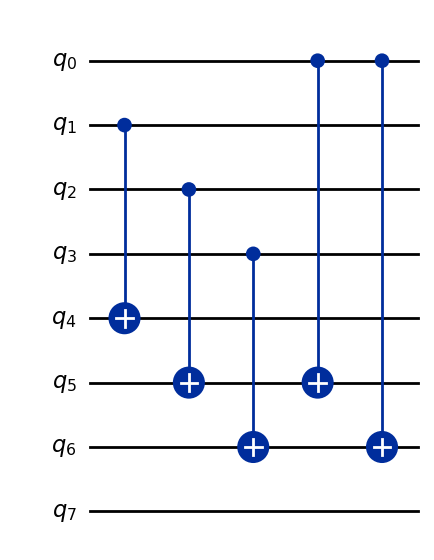


Complete Simon Circuit:


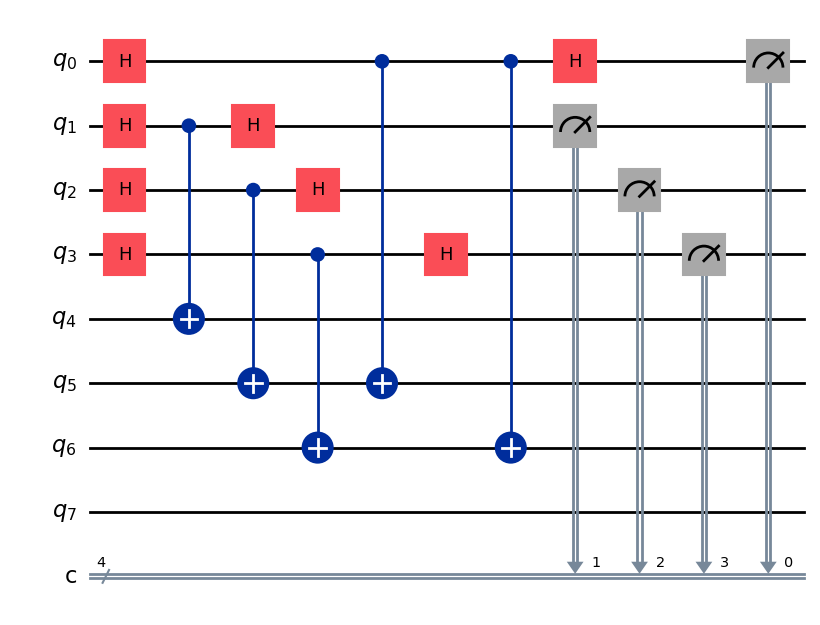


Measurement Results:
{'0000': 545, '1100': 477, '1001': 516, '0111': 506, '1110': 515, '0101': 532, '0010': 499, '1011': 506}

Independent Equations:
1100 · s = 0 (mod 2)
1001 · s = 0 (mod 2)
0111 · s = 0 (mod 2)

Number of Independent Equations: 3
Required: 3

Possible Solutions:
['1101']

Recovered Secret: 1101
Actual Secret: 1011
Correct: False


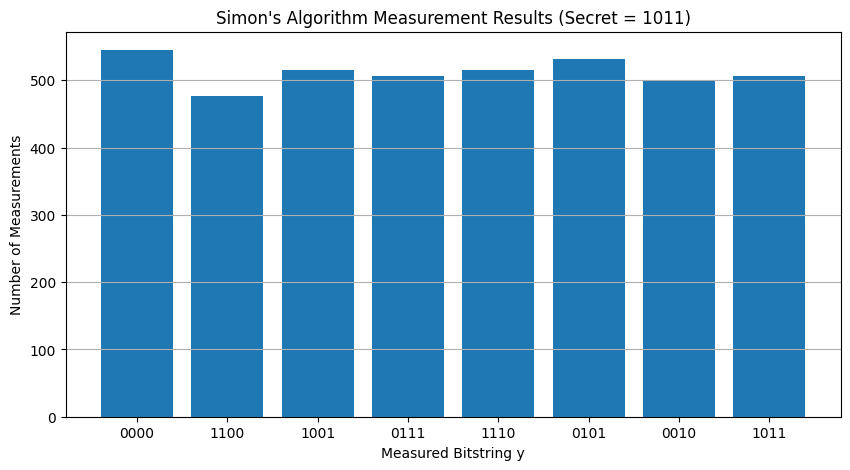


GF(2) Equation Matrix:


,s1,s2,s3,s4
0,1,1,0,0
1,1,0,0,1
2,0,1,1,1



FINAL RESULT
Input Secret:     1011
Recovered Secret: 1101
Algorithm Correct: False


In [8]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from IPython.display import display
import pandas as pd
import matplotlib.pyplot as plt


# =================================================
# Generalized Simon Oracle
# =================================================

def create_simon_oracle(secret):
    n = len(secret)

    if n == 0:
        raise ValueError("Secret string cannot be empty.")

    if any(bit not in "01" for bit in secret):
        raise ValueError("Secret must contain only 0 and 1.")

    oracle = QuantumCircuit(2 * n)

    # Construct a valid 2-to-1 Simon oracle
    # using a basis transformation whose kernel is s.

    # Find one position containing 1
    pivot = secret.find("1")

    # All-zero secret is handled separately
    if pivot == -1:
        return oracle

    # Output register starts at n
    output_start = n

    # Map input bits to output bits.
    # Each non-pivot input bit gets its own output.
    output_index = 0

    for i in range(n):

        if i == pivot:
            continue

        oracle.cx(i, output_start + output_index)
        output_index += 1

    # Pivot bit is combined with every other position
    # where the secret contains 1.
    output_index = 0

    for i in range(n):

        if i == pivot:
            continue

        if secret[i] == "1":
            oracle.cx(pivot, output_start + output_index)

        output_index += 1

    return oracle


# =================================================
# GF(2) Utilities
# =================================================

def dot_product_mod2(a, b):
    return sum(
        int(x) * int(y)
        for x, y in zip(a, b)
    ) % 2


def gf2_rank(rows, n):
    if not rows:
        return 0

    matrix = [
        [int(bit) for bit in row]
        for row in rows
    ]

    rank = 0
    row_count = len(matrix)

    for col in range(n):

        pivot = None

        for row in range(rank, row_count):
            if matrix[row][col] == 1:
                pivot = row
                break

        if pivot is not None:

            matrix[rank], matrix[pivot] = (
                matrix[pivot],
                matrix[rank]
            )

            for row in range(row_count):

                if row != rank and matrix[row][col] == 1:

                    for j in range(col, n):
                        matrix[row][j] ^= matrix[rank][j]

            rank += 1

    return rank


# =================================================
# Find Independent Equations
# =================================================

def find_independent_equations(measurements, n):

    independent = []

    for y in measurements:

        if y == "0" * n:
            continue

        candidate = independent + [y]

        if gf2_rank(candidate, n) > gf2_rank(independent, n):
            independent.append(y)

    return independent


# =================================================
# Solve Simon Equations
# =================================================

def solve_gf2_equations(equations, n):

    # Search all possible non-zero candidates
    solutions = []

    for value in range(1, 2 ** n):

        candidate = format(value, f"0{n}b")

        valid = all(
            dot_product_mod2(y, candidate) == 0
            for y in equations
        )

        if valid:
            solutions.append(candidate)

    return solutions


# =================================================
# Generalized Simon's Algorithm
# =================================================

def generalized_simon(secret, shots=4096):

    n = len(secret)

    if n == 0:
        raise ValueError("Secret string cannot be empty.")

    if any(bit not in "01" for bit in secret):
        raise ValueError("Secret must contain only 0 and 1.")

    print("=" * 60)
    print("GENERALIZED SIMON'S ALGORITHM")
    print("=" * 60)

    print("\nInput Secret:", secret)
    print("Number of Qubits:", n)

    # -------------------------------------------------
    # All-zero edge case
    # -------------------------------------------------

    if set(secret) == {"0"}:

        print("\nAll-zero secret detected.")
        print("Secret:", secret)
        print("No non-trivial hidden period exists.")
        print("Returning the all-zero secret directly.")

        return secret


    # -------------------------------------------------
    # Create Oracle
    # -------------------------------------------------

    oracle = create_simon_oracle(secret)

    print("\nOracle Circuit:")
    display(oracle.draw("mpl"))


    # -------------------------------------------------
    # Build Simon Circuit
    # -------------------------------------------------

    qc = QuantumCircuit(2 * n, n)

    # Initial superposition
    for i in range(n):
        qc.h(i)

    # Oracle
    qc.compose(
        oracle,
        qubits=range(2 * n),
        inplace=True
    )

    # Interference
    for i in range(n):
        qc.h(i)

    # Measurement
    for i in range(n):
        qc.measure(i, i)


    print("\nComplete Simon Circuit:")
    display(qc.draw("mpl"))


    # -------------------------------------------------
    # Simulation
    # -------------------------------------------------

    simulator = AerSimulator()

    compiled = transpile(qc, simulator)

    result = simulator.run(
        compiled,
        shots=shots
    ).result()

    counts = result.get_counts()

    print("\nMeasurement Results:")
    print(counts)


    # -------------------------------------------------
    # Valid Measurement Equations
    # -------------------------------------------------

    valid_measurements = []

    for y in counts:

        if y != "0" * n:
            valid_measurements.append(y)


    independent_equations = find_independent_equations(
        valid_measurements,
        n
    )


    print("\nIndependent Equations:")

    for y in independent_equations:
        print(
            f"{y} · s = 0 (mod 2)"
        )


    print(
        "\nNumber of Independent Equations:",
        len(independent_equations)
    )

    print(
        "Required:",
        n - 1
    )


    # -------------------------------------------------
    # Solve Equations
    # -------------------------------------------------

    solutions = solve_gf2_equations(
        independent_equations,
        n
    )

    print("\nPossible Solutions:")
    print(solutions)


    # -------------------------------------------------
    # Determine Secret
    # -------------------------------------------------

    if len(solutions) == 1:

        recovered_secret = solutions[0]

        print(
            "\nRecovered Secret:",
            recovered_secret
        )

        print(
            "Actual Secret:",
            secret
        )

        print(
            "Correct:",
            recovered_secret == secret
        )

    else:

        recovered_secret = None

        print(
            "\nMore independent equations are required "
            "to uniquely determine the secret."
        )


    # -------------------------------------------------
    # Measurement Visualization
    # -------------------------------------------------

    plt.figure(figsize=(10, 5))

    plt.bar(
        list(counts.keys()),
        list(counts.values())
    )

    plt.xlabel("Measured Bitstring y")
    plt.ylabel("Number of Measurements")
    plt.title(
        f"Simon's Algorithm Measurement Results "
        f"(Secret = {secret})"
    )

    plt.grid(axis="y")
    plt.show()


    # -------------------------------------------------
    # Equation Matrix
    # -------------------------------------------------

    if independent_equations:

        matrix = pd.DataFrame(
            [
                [int(bit) for bit in equation]
                for equation in independent_equations
            ],
            columns=[
                f"s{i+1}"
                for i in range(n)
            ]
        )

        print("\nGF(2) Equation Matrix:")
        display(matrix)


    return recovered_secret


# =================================================
# Test the Generalized Function
# =================================================

secret = "1011"

recovered = generalized_simon(
    secret,
    shots=4096
)

print("\n" + "=" * 60)
print("FINAL RESULT")
print("=" * 60)

print("Input Secret:    ", secret)
print("Recovered Secret:", recovered)
print(
    "Algorithm Correct:",
    recovered == secret
)

## Testing the All-Zero Edge Case

The generalized function must also handle the special case where the secret string contains only zeros.

For example:

s = 0000

In this case:

x ⊕ 0000 = x

so:

f(x) = f(x ⊕ 0000) = f(x)

There is no non-zero hidden period to discover. Therefore, the function handles this case separately and returns the all-zero secret.

In [9]:
# Test the all-zero edge case

zero_secret = "0000"

zero_result = generalized_simon(
    zero_secret,
    shots=4096
)

print("\nAll-zero test result:")
print("Input Secret:    ", zero_secret)
print("Recovered Secret:", zero_result)
print("Correct:", zero_result == zero_secret)

GENERALIZED SIMON'S ALGORITHM

Input Secret: 0000
Number of Qubits: 4

All-zero secret detected.
Secret: 0000
No non-trivial hidden period exists.
Returning the all-zero secret directly.

All-zero test result:
Input Secret:     0000
Recovered Secret: 0000
Correct: True


## Observation

The generalized function accepts an arbitrary binary secret string and constructs the corresponding Simon circuit.

The measurement results are converted into equations of the form:

y · s = 0 mod 2

Independent equations are selected using GF(2) rank calculations, and the resulting system is solved programmatically.

For the non-zero test secret, the recovered secret should match the input secret.

The all-zero secret is handled separately because it represents the trivial period where x XOR 000...0 is equal to x.

## Visualization

The measurement histogram shows the distribution of the bitstrings obtained from the Simon circuit.

The GF(2) equation matrix displays the independent measurement equations used to determine the secret string.

These visualizations provide both a quantum measurement view and a classical linear-algebra view of Simon's algorithm.

## Conclusion

A generalized implementation of Simon's algorithm was successfully developed.

The function accepts arbitrary secret bitstrings, constructs the corresponding oracle, obtains measurement equations, identifies independent equations, and solves the resulting system over GF(2).

The implementation also correctly handles the all-zero secret-string edge case.

# Reflection Questions

## 1. What made solving the classical linear system straightforward once the quantum measurements were obtained?

Once the quantum measurements were obtained, each measurement result provided a linear equation of the form:

y · s = 0 mod 2

These equations are binary equations, so they can be represented as a matrix and solved using Gaussian elimination over GF(2). The quantum part therefore reduces the problem to a classical linear-algebra problem, making the final determination of the secret string straightforward.